# Exploratory Data Analysis (EDA) on Sales Data

This notebook performs a compact exploratory data analysis on a sales dataset, including:
- dataset inspection
- missing value detection
- descriptive statistics
- distribution analysis
- anomaly detection using boxplots
- variable correlation analysis
- relationship exploration between price and sales

The dataset is loaded from the `Machine-Learning-Lab/data/sales_dataset.csv` path, so it works cleanly in a GitHub repository or when cloned to another machine.

c:\Users\Lenovo\OneDrive\Documents\Jupyter\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Lenovo\OneDrive\Documents\Jupyter\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Loading dataset from: C:\Users\Lenovo\OneDrive\Desktop\data-science-playground\data-science-playground\data-science-playground\Machine-Learning-Lab\data\sales_dataset.csv

First 5 Rows:

   OrderID Region     Product  Age   Price  Quantity  Discount(%)    Sales
0     1001   East      Laptop   52  218.45         2           20   349.52
1     1002   West      Laptop   53  244.10         9            5  2087.05
2     1003  North      Tablet   35  156.59         2           10   281.86
3     1004   East      Mobile   56  280.85         5           20  1123.40
4     1005   East  Smartwatch   49  305.75         9            0  2751.75

Dataset Shape: (10, 8)

Missing Values Count:
 OrderID        0
Region         0
Product        0
Age            0
Price          0
Quantity       0
Discount(%)    0
Sales          0
dtype: int64

Statistical Summary:

           OrderID Region Product        Age       Price   Quantity  \
count     10.00000     10      10  10.000000   10.000000  10.000000   
u

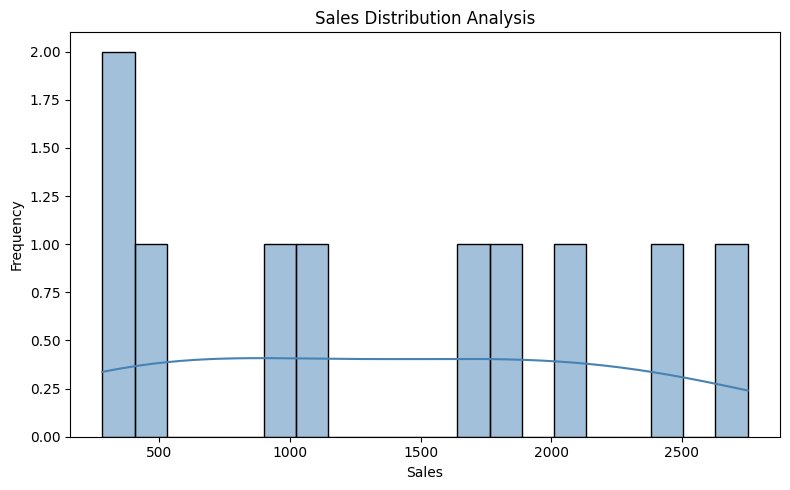

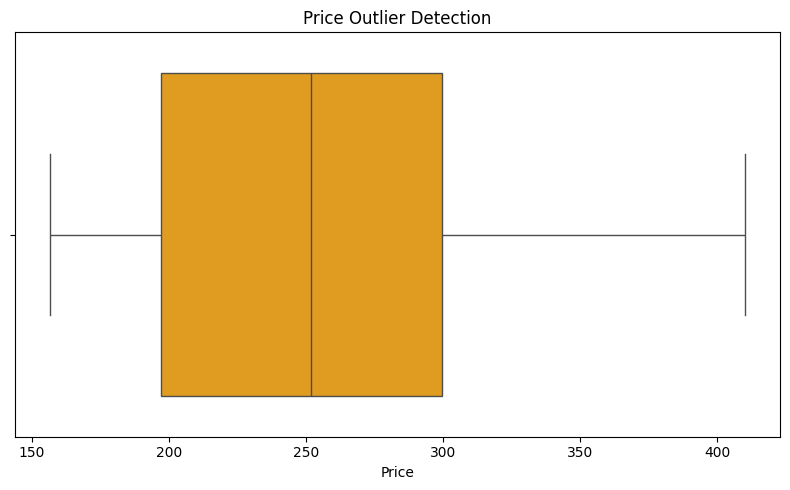

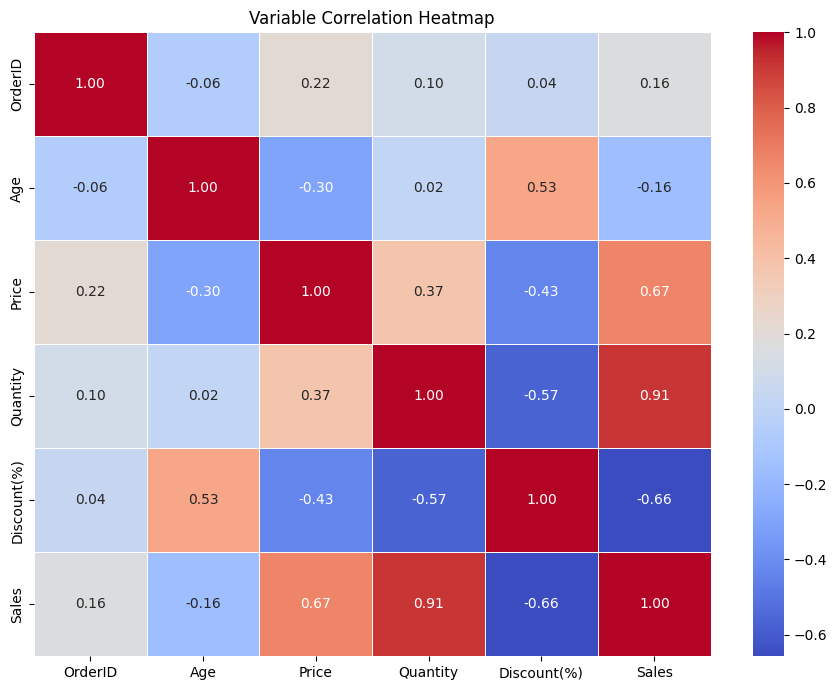

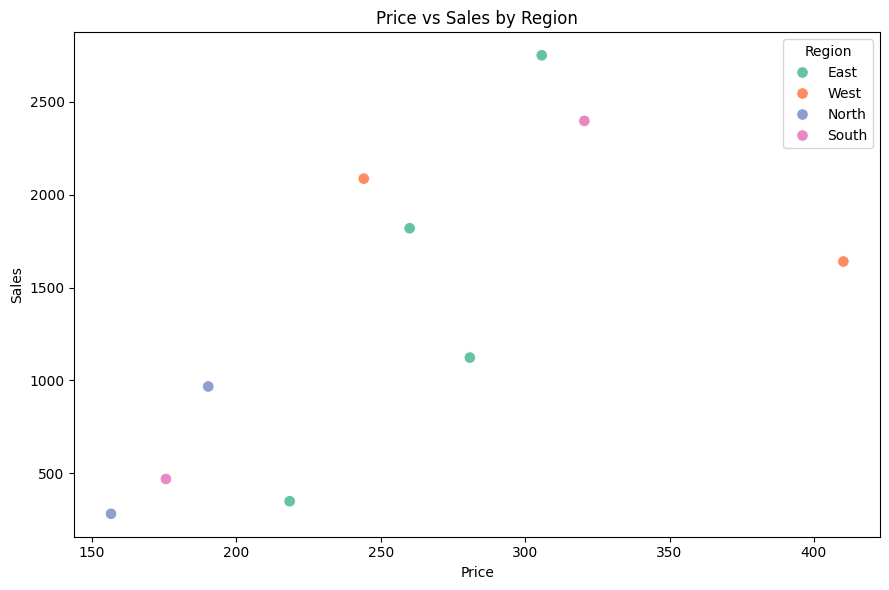


EDA completed successfully.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve the project root relative to this notebook file
project_root = Path.cwd().resolve()
if not (project_root / "Machine-Learning-Lab").exists():
    # Fallback for notebook execution from the repo root or from within Machine-Learning-Lab
    candidate_roots = [
        Path.cwd().resolve(),
        Path.cwd().resolve().parent,
        Path.cwd().resolve().parent.parent,
    ]
    for candidate in candidate_roots:
        if (candidate / "Machine-Learning-Lab").exists():
            project_root = candidate
            break

lab_dir = project_root / "Machine-Learning-Lab"
if not lab_dir.exists():
    raise FileNotFoundError(
        "Could not locate 'Machine-Learning-Lab'. "
        "Please run this notebook from the project root or a subfolder inside the repository."
    )

data_path = lab_dir / "data" / "sales_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at expected path: {data_path}")

print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)

print("\nFirst 5 Rows:\n")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values Count:\n", df.isnull().sum())
print("\nStatistical Summary:\n")
print(df.describe(include='all'))

# Distribution of Sales
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=20, kde=True, color="steelblue")
plt.title("Sales Distribution Analysis")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Anomaly detection in Price
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Price"], color="orange")
plt.title("Price Outlier Detection")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Variable Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatterplot by Region
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Price", y="Sales", hue="Region", palette="Set2", s=70)
plt.title("Price vs Sales by Region")
plt.xlabel("Price")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

print("\nEDA completed successfully.")